In [9]:
import pandas as pd
import numpy as np
from scipy import stats

from pandas.api.types import CategoricalDtype

stationProximityDataSet: pd.DataFrame = pd.read_csv("data/benz-tr.csv")

stationProximityDataSet = stationProximityDataSet[stationProximityDataSet["city"].str.startswith("praha", na=False)]

print("\nCount of transactions in Czechia: ", stationProximityDataSet.shape[0])

duplicateSubset = subset=["amt", "day", "hour", "clid"]
print('\nCount of duplicated rows: ',
      sum(stationProximityDataSet.duplicated(subset=duplicateSubset)))

stationProximityDataSet = stationProximityDataSet.drop_duplicates(subset=duplicateSubset)

stationProximityDataSet = stationProximityDataSet.drop(columns=["clst", "clid", "day", "hour", "fav", "fav_main", "cl_gps_lat", "cl_gps_lon", "city", "name", "dist", "country"])

stationsWithDifferingGPS = stationProximityDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

duplicateSubset = ["gps_lat", "gps_lon"]

print('\nCount of duplicated gps locations: ',
      sum(stationsWithDifferingGPS.duplicated(subset=duplicateSubset)))

stationsWithDifferingGPS = stationProximityDataSet.groupby("posid", as_index=False).agg(
    total_amt=("amt", "sum"),
    gps_lat=("pos_gps_lat", lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    gps_lon=("pos_gps_lon", lambda x: x.mode()[0] if not x.mode().empty else np.nan)
)

stationsWithDifferingGPS = stationsWithDifferingGPS.groupby(['gps_lat', 'gps_lon'], as_index=False).agg(
    total_amt=('total_amt', 'sum'),
    posid=('posid', 'first')
)

print('Count of stations', stationsWithDifferingGPS.shape[0])
stationsWithDifferingGPS


Count of transactions in Czechia:  190869

Count of duplicated rows:  70

Count of duplicated gps locations:  159
Count of stations 58


,gps_lat,gps_lon,total_amt,posid
0,49.927433,14.270890,175490.00,7338
1,49.964367,14.381381,521930.20,7385
2,49.998700,14.486550,567600.86,7352
3,50.014519,14.425369,14051268.04,7606
4,50.026707,14.299823,377232.51,7377
5,50.029950,14.517620,240752.00,7364
6,50.030659,14.380275,28854.00,7674
7,50.031014,14.528496,1060064.30,7367
8,50.032900,14.424200,33543.50,7461
9,50.033016,14.424053,275083.70,7353


In [10]:

networkStationPairs = pd.DataFrame = pd.read_csv("./data/network_station_pairs_prague_only.csv")

stationsWithDifferingGPS = stationsWithDifferingGPS.drop(columns=["gps_lat", "gps_lon"])

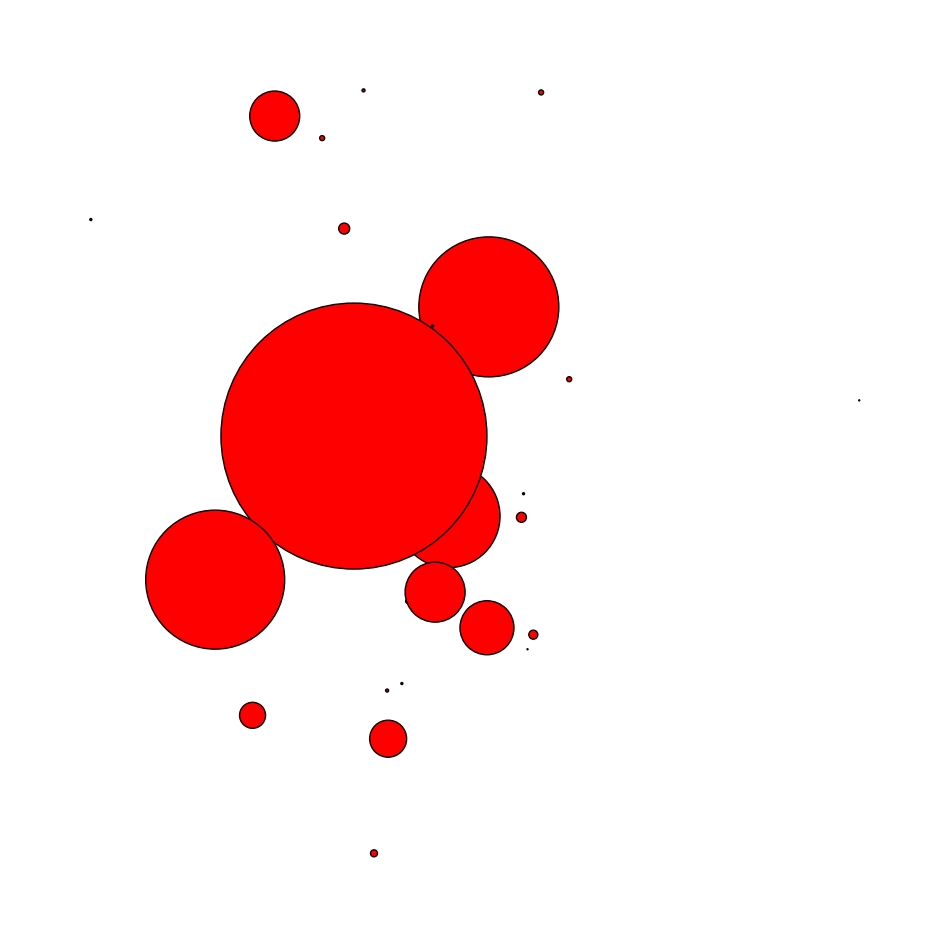

In [11]:
import igraph as ig
import matplotlib.pyplot as plt

g = ig.Graph.TupleList(networkStationPairs.itertuples(index=False), weights=True)

node_sizes = dict(zip(stationsWithDifferingGPS["posid"], stationsWithDifferingGPS["total_amt"].apply(lambda x: x / 100000)))

g.vs["size"] = [node_sizes.get(posid, 1) for posid in g.vs["name"]]

layout = g.layout("kamada_kawai", weights=g.es["weight"])

fig, ax = plt.subplots(figsize=(12, 12))  # Larger figure size for better visualization
ig.plot(g, layout=layout, target=ax, vertex_size=g.vs["size"], bbox=(0, 0, 1000, 1000), edge_width=0)

plt.show()